In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
import sys
import copy
import globin

In [78]:
ref = globin.Atmosphere("atmos_bezier_20240918.fits", atm_range=[0,2,0,3])

In [75]:
inverter = globin.Inverter(verbose=False)
inverter.read_input(run_name="dummy")

inverter.atmosphere.atomic_number = np.array([26], dtype=np.int32)
inverter.atmosphere.atomic_abundance = np.array([7.44], dtype=np.float64)

inverter.atmosphere.get_atomic_rfs = True

inv_atmos, inv, chi2 = inverter.run()

if inv_atmos.global_pars["loggf"].size>0:
    print(inv_atmos.global_pars["loggf"][0,0])
print(chi2.get_final_chi2()[0])

[Warning] We are ignoring the stray light contribution.

-------------------------- Entering inversion mode 1 ---------------------------



100%|██████████| 6/6 [00:36<00:00,  6.10s/it]

[2026-02-23 09:08:34] Finished in: 36.63s

[[1.69093601e-02 2.26479047e-02 9.19838073e-04]
 [6.15386664e-01 2.33422962e-04 6.74007645e-01]]


In [79]:
for idx in range(inv_atmos.nx):
    for idy in range(inv_atmos.ny):
        print(ref.values["vmic"][idx,idy,0], inv_atmos.values["vmic"][idx,idy,0])

0.25 0.25015699784315065
0.5 0.4999869707622055
0.75 0.7500047733380372
1.0 1.0001065930248692
1.25 1.2500046014310724
1.5 1.5000216374139501


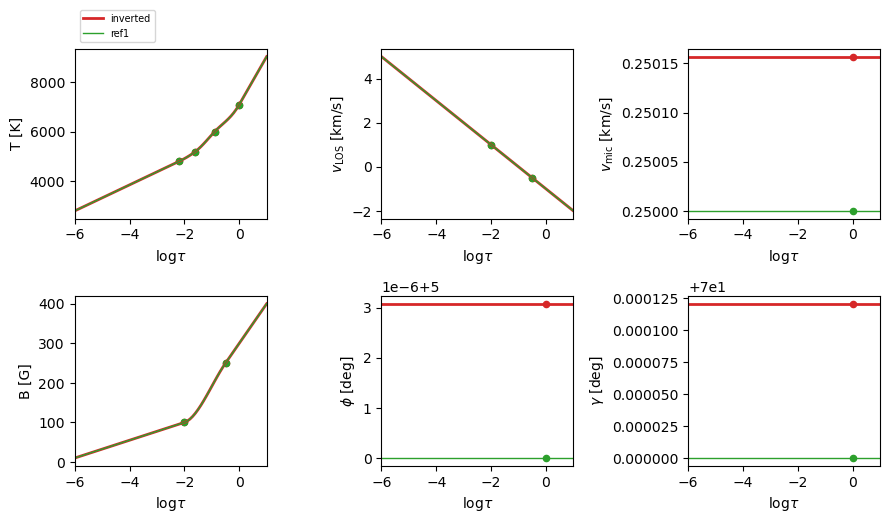

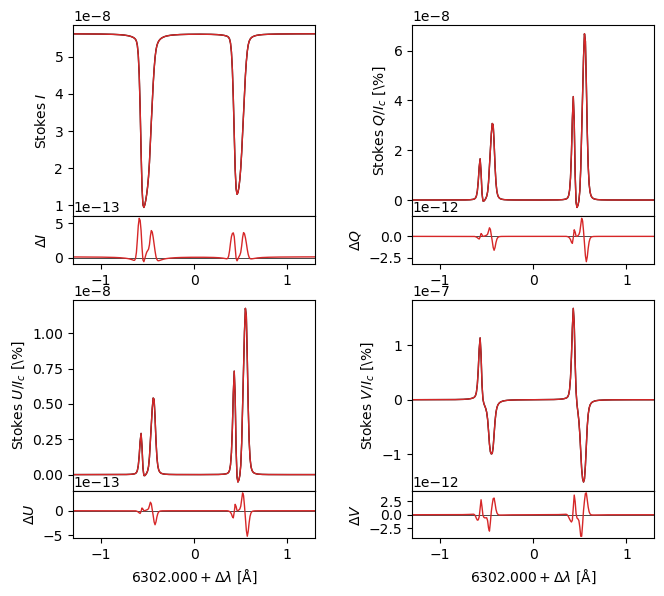

In [80]:
idx, idy = 0, 0
globin.plot_atmosphere(inv_atmos, ["temp", "vz", "vmic", "mag", "chi", "gamma"], reference=ref, idx=idx, idy=idy)
globin.plot_spectra(inverter.observation.spec[idx,idy], inverter.observation.wavelength, inv=inv.spec[idx,idy])
plt.show()